# 06 · LLM Router：由模型选择 TEU 或规则审核工具

用户输入直接进入 llm_router。模型同时看到两个工具 schema，并通过 AIMessage.tool_calls 选择具体工具：

User input → llm_router.bind_tools(TOOLS) → 按 tool_call.name 分支 → 对应 ToolNode → ToolMessage

- calculate_teu：沿用 05 的 TEU 计算工具。
- rule_precheck_service：规则审核服务；课堂故障注入会稳定超时，为 07 的 HITL 铺垫。

这里不再使用 rules_agent/docs_agent 返回固定文本，也没有关键词 Router 提前替模型决定工具。条件边只读取模型已经输出的 tool_call.name。


In [12]:
from __future__ import annotations

import os
from collections import defaultdict
from pathlib import Path

from dotenv import load_dotenv


def find_repo_root() -> Path:
    """向上找到训练仓根目录，避免 Notebook 工作目录变化。"""
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / ".env.example").exists():
            return candidate
    return here


ROOT = find_repo_root()
os.chdir(ROOT)
load_dotenv(ROOT / ".env")

LIVE_MODEL_CONFIGURED = bool(
    (os.getenv("LLM_BASE_URL") or "").strip()
    and (os.getenv("LLM_MODEL") or "").strip()
)
USE_LIVE_MODEL = LIVE_MODEL_CONFIGURED and os.getenv("DAY1_DETERMINISTIC", "0") != "1"

print("cwd =", ROOT)
print("mode =", "live LLM router" if USE_LIVE_MODEL else "deterministic protocol replay")


cwd = /Users/kunwei/Projects/oocl-agent-workshop-lab/oocl-2026-ai-agent-training
mode = live LLM router


In [13]:
def show_graph(graph):
    """在 Notebook 中展示 State / Node / Edge。"""
    from IPython.display import Image, display

    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as exc:
        print("PNG 不可用，打印 Mermaid：", exc)
        print(graph.get_graph().draw_mermaid())


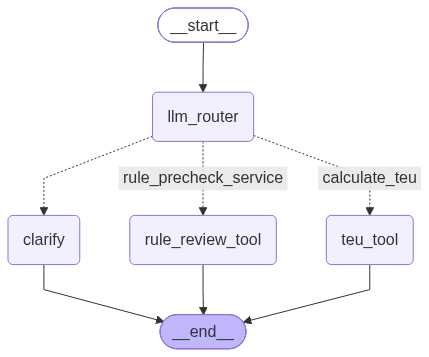

In [14]:
from typing import Annotated, Literal, TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


class RouteState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    status: str
    selected_tool: str
    trace: list[str]


TEU_PER_EQUIPMENT = {"20GP": 1, "40GP": 2, "40HQ": 2}
SERVICE_CALLS = defaultdict(int)


@tool
def calculate_teu(equipment: str, quantity: int) -> int:
    """按课堂约定换算 TEU。支持 20GP、40GP、40HQ。"""
    key = equipment.strip().upper()
    if key not in TEU_PER_EQUIPMENT:
        raise ValueError(f"不支持的箱型: {equipment}")
    if quantity < 0:
        raise ValueError("quantity 不能为负数")
    return TEU_PER_EQUIPMENT[key] * quantity


@tool
def rule_precheck_service(booking_id: str) -> dict:
    """按订舱 ID 调用规则审核服务；课堂故障注入会稳定返回网络超时。"""
    SERVICE_CALLS[booking_id] += 1
    raise TimeoutError(f"RULE_PRECHECK_TIMEOUT: booking_id={booking_id}")


TOOLS = [calculate_teu, rule_precheck_service]


def make_model():
    """通过统一入口创建 OpenAI-compatible 模型，不直接导入 ChatOpenAI。"""
    return init_chat_model(
        model=os.environ["LLM_MODEL"],
        model_provider="openai",
        base_url=os.environ["LLM_BASE_URL"],
        api_key=os.getenv("LLM_API_KEY") or "not-required",
        temperature=0,
    )


base_model = make_model() if USE_LIVE_MODEL else None
model_with_tools = base_model.bind_tools(TOOLS) if base_model is not None else None


def llm_router(state: RouteState) -> dict:
    response = model_with_tools.invoke([
        SystemMessage(content=(
            "根据用户输入自行判断意图，并选择至多一个工具。"
            "TEU 或箱量换算调用 calculate_teu；订舱规则审核调用 rule_precheck_service。"
            "信息不足时不要调用工具，只提出一个澄清问题。不得自行生成工具结果。"
        )),
        *state["messages"],
    ])
    source = "llm"
    return {"messages": [response], "trace": [f"llm_router:{source}"]}


RouteKey = Literal["calculate_teu", "rule_precheck_service", "clarify"]


def clarify(state: RouteState) -> dict:
    return {"status": "need_clarification", "trace": ["llm_router:no_tool_call"]}


# 两个业务能力都由 ToolNode 包装；不再使用返回固定文本的伪 Agent 函数。
teu_tool_node = ToolNode([calculate_teu], handle_tool_errors=True)
rule_review_tool_node = ToolNode([rule_precheck_service], handle_tool_errors=True)

# path_map：路由函数返回值 → 实际节点名
ROUTES: dict[RouteKey, str] = {
    "calculate_teu": "teu_tool",
    "rule_precheck_service": "rule_review_tool",
    "clarify": "clarify",
}


def route_after_llm(state: RouteState) -> RouteKey:
    """条件边 path：只读模型已输出的 tool_call.name，不在此做意图关键词判断。"""
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.tool_calls:
        tool_name = last.tool_calls[0]["name"]
        if tool_name in ROUTES:
            return tool_name  # type: ignore[return-value]
    return "clarify"


builder = StateGraph(RouteState)
builder.add_node("llm_router", llm_router)
builder.add_node("teu_tool", teu_tool_node)
builder.add_node("rule_review_tool", rule_review_tool_node)
builder.add_node("clarify", clarify)
builder.add_edge(START, "llm_router")
# 第 2 参是路由函数；第 3 参才是 path_map（ROUTES）
builder.add_conditional_edges("llm_router", route_after_llm, ROUTES)
for node_name in ["teu_tool", "rule_review_tool", "clarify"]:
    builder.add_edge(node_name, END)

graph = builder.compile()
show_graph(graph)


In [15]:
cases = [
    ("请计算 2×40HQ 的 TEU", "calculate_teu"),
    ("请审核订舱 BK-DEMO-006 的适用规则", "rule_precheck_service"),
]

for question, expected_tool in cases:
    result = graph.invoke({"messages": [HumanMessage(content=question)], "trace": []})
    tool_calls = [
        call
        for message in result["messages"]
        if isinstance(message, AIMessage)
        for call in message.tool_calls
    ]
    tool_messages = [message for message in result["messages"] if isinstance(message, ToolMessage)]
    tool_call = tool_calls[-1]
    tool_message = tool_messages[-1]

    print("Q:", question)
    print("LLM selected:", tool_call)
    print("ToolMessage:", {
        "name": tool_message.name,
        "tool_call_id": tool_message.tool_call_id,
        "status": getattr(tool_message, "status", None),
        "content": tool_message.content,
    })
    print("---")

    assert tool_call["name"] == expected_tool
    assert tool_message.name == expected_tool
    assert tool_message.tool_call_id == tool_call["id"]

assert calculate_teu.invoke({"equipment": "40HQ", "quantity": 2}) == 4
assert SERVICE_CALLS["BK-DEMO-006"] == 1
print("06 LLM Router + two ToolNode branches done")


Q: 请计算 2×40HQ 的 TEU
LLM selected: {'name': 'calculate_teu', 'args': {'equipment': '40HQ', 'quantity': 2}, 'id': 'call_00_eH6ZIfLSt8oU4vP4zwA94678', 'type': 'tool_call'}
ToolMessage: {'name': 'calculate_teu', 'tool_call_id': 'call_00_eH6ZIfLSt8oU4vP4zwA94678', 'status': 'success', 'content': '4'}
---
Q: 请审核订舱 BK-DEMO-006 的适用规则
LLM selected: {'name': 'rule_precheck_service', 'args': {'booking_id': 'BK-DEMO-006'}, 'id': 'call_00_CLNtMrRB0zPQAUmGv67I2902', 'type': 'tool_call'}
ToolMessage: {'name': 'rule_precheck_service', 'tool_call_id': 'call_00_CLNtMrRB0zPQAUmGv67I2902', 'status': 'error', 'content': "Error: TimeoutError('RULE_PRECHECK_TIMEOUT: booking_id=BK-DEMO-006')\n Please fix your mistakes."}
---
06 LLM Router + two ToolNode branches done
